In [1]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import warnings
warnings.filterwarnings('ignore')

# Data Exploration and Cleaning

In [2]:
df = pd.read_csv("../notebooks/data/enron_spam_data.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  33716 non-null  int64
 1   Subject     33716 non-null  str  
 2   Message     33664 non-null  str  
 3   Spam/Ham    33716 non-null  str  
 4   Date        33716 non-null  str  
dtypes: int64(1), str(4)
memory usage: 1.3 MB


In [4]:
df.shape

(33716, 5)

In [5]:
df.sample(5)

,Unnamed: 0,Subject,Message,Spam/Ham,Date
15628,15628,re : releases,"louise ,\nthanks so much for your speedy reply...",spam,2004-12-30
28511,28511,fw : transwestern capacity release report,- - - - - original message - - - - -\nfrom : e...,ham,2001-03-05
10889,10889,fw : memo : re : your work phone number,"hi ,\ni am forwarding an email from a former b...",spam,2005-07-19
9709,9709,fw : memo : re : your work phone number,"hi ,\ni am forwarding an email from a former b...",spam,2002-07-21
3665,3665,fw : revised : gas logistics netco restart,"fyi - this is the "" day 1 "" list that you work...",ham,2002-01-08


In [6]:
df.isnull().sum()

Unnamed: 0     0
Subject        0
Message       52
Spam/Ham       0
Date           0
dtype: int64

In [7]:
df["Spam/Ham"].value_counts()

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64

In [8]:
df[df["Message"].isnull()].head(5)

,Unnamed: 0,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
183,183,day 26 - txu lonestar called on 20000 at carthage,NaN,ham,2000-01-25
199,199,is this fri feb 11 a problem for taking vacati...,NaN,ham,2000-01-28
304,304,http : / / www . pge - texas . com / www / gtt...,NaN,ham,2000-02-15
1655,1655,revised,NaN,ham,2000-09-21


In [9]:
df["Message"] = df["Message"].fillna("")

In [10]:
df.isna().sum()

Unnamed: 0    0
Subject       0
Message       0
Spam/Ham      0
Date          0
dtype: int64

In [11]:
df.describe(include='all')

,Unnamed: 0,Subject,Message,Spam/Ham,Date
count,33716.000000,33716,33716,33716,33716
unique,NaN,12773,15794,2,1527
top,NaN,fw : re ivanhoe e . s . d,start date : 2 / 6 / 02 ; hourahead hour : 24 ...,spam,2005-07-19
freq,NaN,4502,4501,17171,457
mean,16857.500000,NaN,NaN,NaN,NaN
std,9733.115174,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN
25%,8428.750000,NaN,NaN,NaN,NaN
50%,16857.500000,NaN,NaN,NaN,NaN
75%,25286.250000,NaN,NaN,NaN,NaN


In [12]:
df["text"] = df["Subject"] + " " + df["Message"]

In [13]:
df.head(2)

,Unnamed: 0,Subject,Message,Spam/Ham,Date,text
0,0,christmas tree farm pictures,,ham,1999-12-10,christmas tree farm pictures
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,"vastar resources , inc . gary , production fro..."


In [14]:
df["label"] = df["Spam/Ham"].map({
    "ham":0,
    "spam":1
})

In [15]:
df.sample(2)

,Unnamed: 0,Subject,Message,Spam/Ham,Date,text,label
30834,30834,fw : re ivanhoe e . s . d,"fyi , kim .\n- - - - - original message - - - ...",spam,2004-12-18,"fw : re ivanhoe e . s . d fyi , kim .\n- - - -...",1
18094,18094,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...,spam,2003-12-29,start date : 2 / 6 / 02 ; hourahead hour : 24 ...,1


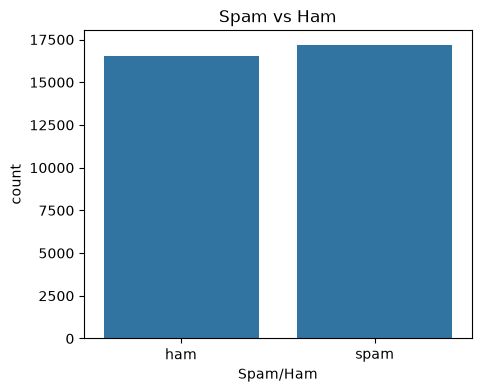

In [16]:
plt.figure(figsize=(5,4))
sns.countplot(data=df,x="Spam/Ham")
plt.title("Spam vs Ham")
plt.show()

In [17]:
df["word_count"] = df["text"].str.split().str.len()

In [18]:
df.head(2)

,Unnamed: 0,Subject,Message,Spam/Ham,Date,text,label,word_count
0,0,christmas tree farm pictures,,ham,1999-12-10,christmas tree farm pictures,0,4
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,"vastar resources , inc . gary , production fro...",0,1577


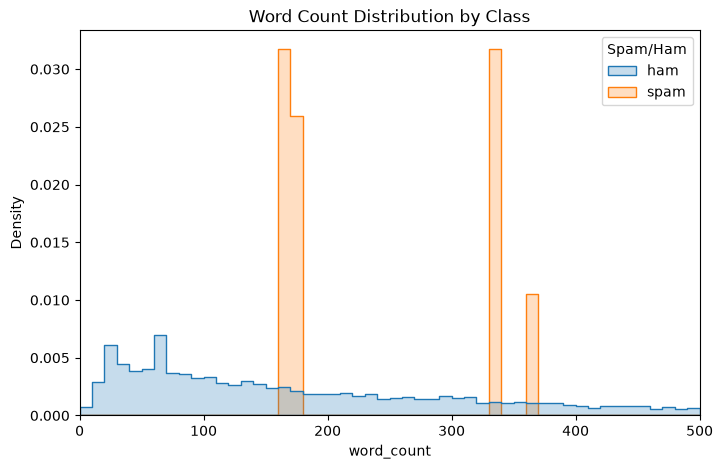

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="word_count", hue="Spam/Ham", bins=50,
             binrange=(0, 500), element="step", stat="density", common_norm=False)
plt.title("Word Count Distribution by Class")
plt.xlim(0,500)
plt.show()

In [20]:
def top_words(text, n=20):
    words = re.findall(r"[a-z]{3,}", " ".join(text).lower())
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]

    return Counter(words).most_common(n)

In [21]:
spam_words = top_words(df[df["Spam/Ham"]=="spam"]["text"])
ham_words = top_words(df[df["Spam/Ham"]=="ham"]["text"])

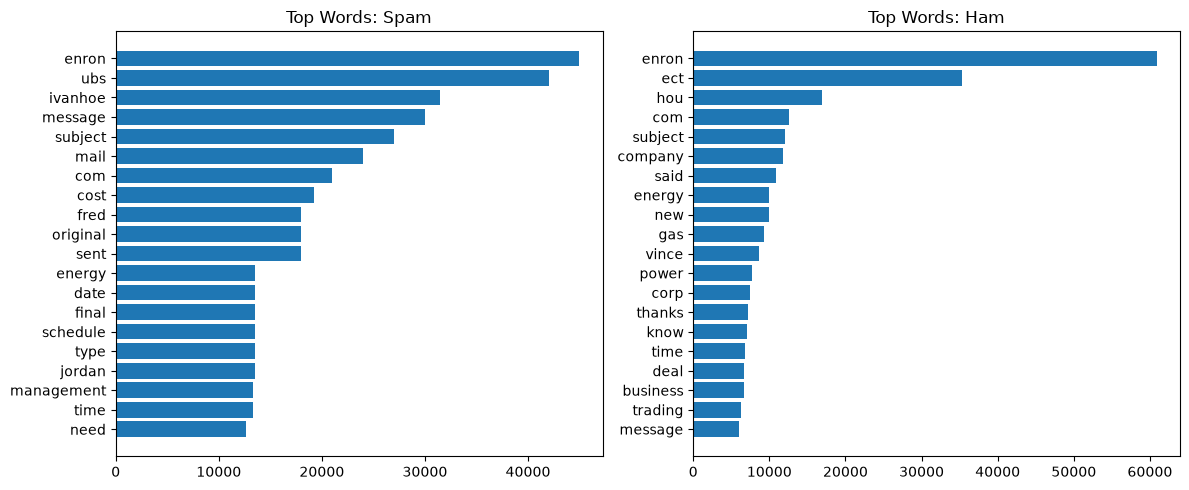

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title in [(axes[0], spam_words, "Top Words: Spam"),
                         (axes[1], ham_words, "Top Words: Ham")]:
    words, counts = zip(*data)
    ax.barh(words[::-1], counts[::-1])
    ax.set_title(title)
plt.tight_layout()

In [23]:
wc_spam = WordCloud(background_color="white").generate(
    " ".join(df[df["Spam/Ham"] == "spam"]["text"]))
wc_ham = WordCloud(background_color="white").generate(
    " ".join(df[df["Spam/Ham"] == "ham"]["text"]))

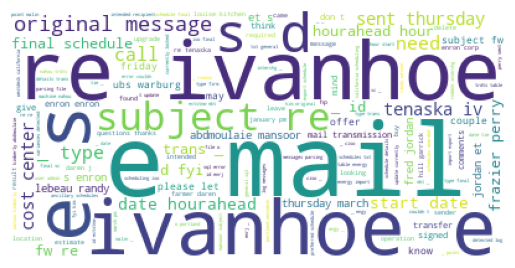

In [24]:
plt.imshow(wc_spam)
plt.axis("off")
plt.show()

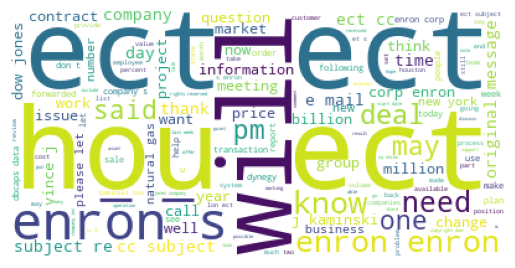

In [25]:
plt.imshow(wc_ham)
plt.axis("off")
plt.show()

# Model Training

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

In [27]:
tfidf = TfidfVectorizer(stop_words="english", max_features=20000,
                         ngram_range=(1, 2), min_df=2)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [28]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
}


 Naive Bayes
accuracy=0.9911 precision=0.9828 recall=1.0000 f1=0.9913 roc_auc=0.9997
              precision    recall  f1-score   support

         ham       1.00      0.98      0.99      3309
        spam       0.98      1.00      0.99      3435

    accuracy                           0.99      6744
   macro avg       0.99      0.99      0.99      6744
weighted avg       0.99      0.99      0.99      6744


 Logistic Regression
accuracy=0.9994 precision=0.9988 recall=1.0000 f1=0.9994 roc_auc=0.9998
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00      3309
        spam       1.00      1.00      1.00      3435

    accuracy                           1.00      6744
   macro avg       1.00      1.00      1.00      6744
weighted avg       1.00      1.00      1.00      6744



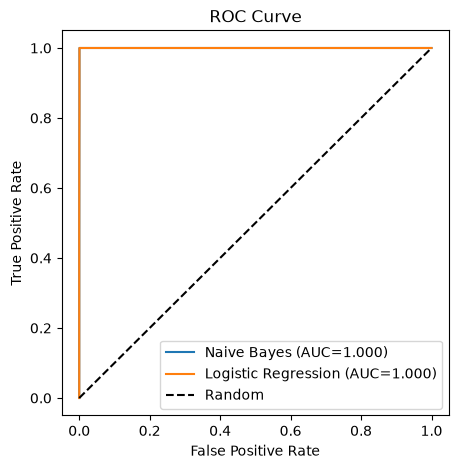


Best model: Logistic Regression (F1 score: 0.9994)


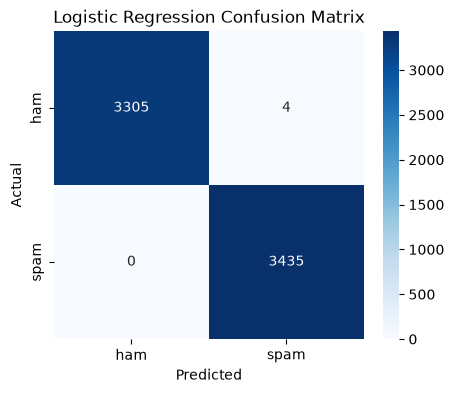

In [29]:
best_name, best_model, best_f1, best_preds = None, None, 0, None

plt.figure(figsize=(5, 5))
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    proba = model.predict_proba(X_test_vec)[:, 1]
 
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
 
    print(f"\n {name}")
    print(f"accuracy={acc:.4f} precision={prec:.4f} recall={rec:.4f} f1={f1:.4f} roc_auc={auc:.4f}")
    print(classification_report(y_test, preds, target_names=["ham", "spam"]))
 
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
 
    if f1 > best_f1:
        best_name, best_model, best_f1, best_preds = name, model, f1, preds

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
 
print(f"\nBest model: {best_name} (F1 score: {best_f1:.4f})")
 
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"{best_name} Confusion Matrix")
plt.show()
plt.close()